In [676]:
%load_ext autoreload
%autoreload 2

/Users/benedikt/tugraz/cgv/hereditary/gutbrainie/submission/../constrerl/utils.py:152: SyntaxWarning: invalid escape sequence '\c'
  result_dict[k] = tf[v]
/Users/benedikt/tugraz/cgv/hereditary/gutbrainie/submission/../constrerl/utils.py:152: SyntaxWarning: invalid escape sequence '\c'
  result_dict[k] = tf[v]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [677]:
import sys

sys.path.append("..")

In [678]:
from constrerl.eval.evaluate import (
    eval_submission_concept_level_RE,
    eval_submission_mention_level_RE,
    eval_submission_NER,
    eval_submission_NERD,
    remove_duplicated_entities,
    remove_overlapping_entities,
    remove_duplicated_concept_level_relations,
    remove_duplicated_mention_level_relations
)
from constrerl.erl_schema import AnnotatedArticle
import glob
from pathlib import Path
import json
import pandas as pd
from collections.abc import Callable

import re


In [679]:
report_dir = Path("report")

results_dir = "../data/merge_dev"
lbl_xtra = ":merge_dev"
report_dir = report_dir / "dev-tugw"
merge_caption = ", including the results of the merged approaches with Graphwise."
mode = "Merged Development"
# report_dir = report_dir / "dev"
# results_dir = "../data/results_dev"
# merge_caption = "."
# lbl_xtra = ":results_dev"
# mode = "Development"

ground_truth_file = "../data/Annotations/Dev/json_format/dev.json"
report_dir.mkdir(exist_ok=True, parents=True)
results_dir = Path(results_dir)
ground_truth_file = Path(ground_truth_file)




k_limits = [None]

with open(ground_truth_file) as f:
    ground_truth = json.load(f)
ground_truth_articles: dict[str, AnnotatedArticle] = {}
for k, v in ground_truth.items():
    ground_truth_articles[k] = AnnotatedArticle.model_validate(v)

In [680]:
from inference import AnnotationTypes
from constrerl.utils import extract_flags_from_name


eval_results: list[dict] = []


def scoring_to_dict(
    predictions: dict, eval_f: Callable[[dict, dict], tuple[float]], gt=ground_truth
) -> dict:
    precision, recall, f1, micro_precision, micro_recall, micro_f1 = eval_f(
        predictions, gt
    )
    return {
        "$P$": precision,
        "$R$": recall,
        "$F_1$": f1,
        "$P_{micro}$": micro_precision,
        "$R_{micro}$": micro_recall,
        "$F_{1,micro}$": micro_f1,
    }


def scoring_to_df(
    eval_f: Callable[[str | Path, dict], tuple[float]],
    key: str,
    res_dir=results_dir,
    k_limits_set=None,
    cap_gt=False,
    typ: AnnotationTypes | None = None,
) -> pd.DataFrame:
    eval_results: list[dict] = []
    merge_mode = "merge" in str(res_dir)
    further_mode = False  # not (("old" in str(res_dir)) or ("merge" in str(res_dir)))
    print(f"Further mode: {further_mode}")
    files = list(res_dir.glob("*.json"))
    print(f"Found {len(files)} json files in {res_dir}.")
    if not res_dir.is_dir():
        files = [res_dir]
    for result_file in files:
        result_file = Path(result_file)
        if typ is not None and (typ.value not in result_file.name):
            if "base" not in result_file.name:
                continue

        print(
            "Considering file:",
            result_file,
            "with k limits:",
            k_limits_set,
            "for finetune type:",
            typ,
        )
        try:
            with open(result_file, "r", encoding="utf-8") as file:
                predictions: dict = json.load(file)
        except OSError:
            raise OSError(f"Error in opening the specified json file: {result_file}")

        if k_limits_set is None or len(k_limits_set) == 0:
            k_list = [None]
        else:
            k_list = k_limits_set
        for k in k_list:
            predictions_limited = predictions.copy()
            predictions_limited = {
                id: {
                    key: predictions_limited[id][key][:k]
                    if key in predictions_limited[id]
                    else []
                }
                for id in predictions_limited.keys()
            }
            all_empty = True
            for id in predictions_limited.keys():
                if len(predictions_limited[id][key]) > 0:
                    all_empty = False
                    break
            if all_empty:
                print(f"Skipping {k}/{result_file} due to all empty predictions.")
                continue
            k_gt: dict = ground_truth.copy()
            if cap_gt:
                k_gt = {id: {key: k_gt[id][key][:k]} for id in k_gt.keys()}

            eval_result = None
            try:
                eval_result = scoring_to_dict(predictions_limited, eval_f, gt=k_gt)
            except Exception as e:
                print(f"Error in evaluating {result_file} with k={k}: {e}")
                continue
            all_zero = all(v == 0.0 for v in eval_result.values())
            if all_zero:
                print(f"Skipping {k}/{result_file} due to all zero scores.")
                continue
            result_dict = extract_flags_from_name(
                result_file.name, merge_mode=merge_mode, k=k
            )
            result_dict.update(eval_result)
            # result_dict.update({f"6_2_2_{k}": v for k, v in ternary_tag_score.items()})
            # result_dict.update({f"6_2_3_{k}": v for k, v in ternary_mention_score.items()})
            eval_results.append(result_dict)
    eval_df = pd.DataFrame(eval_results)
    # if further_mode and "$k$" not in eval_df.columns:
    #     eval_df = eval_df[(eval_df["Long $t$"] == "\checkmark")]
    # if merge_mode:
    #     eval_df = eval_df[eval_df["Model"].str.contains("Hermes 3B")]
    valid_cols = [
        c
        for c in [
            "Graphwise",
            "Set",
            "Model",
            "Beams",
            "NED FT",
            "RAG",
            "LoRA",
            "Naive",
            "Filter",
        ]
        if c in eval_df.columns
    ]
    print(
        f"Valid columns for indexing: {valid_cols} (from {eval_df.columns.tolist()}), found result: {len(eval_df)}"
    )
    eval_df.set_index(valid_cols, inplace=True)
    eval_df = eval_df.sort_index()
    # if "$F_{1,micro}$" in eval_df.columns:
    #     eval_df = eval_df.sort_values("$F_{1,micro}$")
    return eval_df


task_6_1_1_df = scoring_to_df(
    eval_submission_NER, "entities", typ=AnnotationTypes.ENTITY
)
task_6_1_2_df = scoring_to_df(
    eval_submission_NERD, "entities", typ=AnnotationTypes.ENTITY
)
task_6_2_1_df = scoring_to_df(
    eval_submission_mention_level_RE,
    "mention_level_relations",
    typ=AnnotationTypes.RELATION,
)
task_6_2_2_df = scoring_to_df(
    eval_submission_concept_level_RE,
    "concept_level_relations",
    typ=AnnotationTypes.RELATION,
)

Further mode: False
Found 20 json files in ../data/merge_dev.
Considering file: ../data/merge_dev/eval_hermes_neefinetuned-lora-entities-naive-beam-none-hermes-3-2-3B_Graphwise_T611_13_NER-EXP-8-SUB-1-DEV-EL_freq_gaze_intersection.json with k limits: None for finetune type: AnnotationTypes.ENTITY
Considering file: ../data/merge_dev/eval_naive-entities_Graphwise_T611_13_NER-EXP-8-SUB-1-DEV-EL_freq_gaze_union.json with k limits: None for finetune type: AnnotationTypes.ENTITY


=== Removed 6645 duplicated entities from predictions ===
=== Removed 4302 overlapping entities ===
Considering file: ../data/merge_dev/eval_naive-entities_Graphwise_T611_13_NER-EXP-8-SUB-1-DEV-EL_freq_gaze_intersection.json with k limits: None for finetune type: AnnotationTypes.ENTITY
Considering file: ../data/merge_dev/eval_naive-entities_Graphwise_T611_13_NER-EXP-8-SUB-1-DEV_intersection.json with k limits: None for finetune type: AnnotationTypes.ENTITY
Skipping None/../data/merge_dev/eval_naive-entities_Graphwise_T611_13_NER-EXP-8-SUB-1-DEV_intersection.json due to all empty predictions.
Considering file: ../data/merge_dev/eval_hermes_neefinetuned-lora-entities-naive-beam-none-hermes-3-2-3B_Graphwise_T611_13_NER-EXP-8-SUB-1-DEV_union.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 8841 duplicated entities from predictions ===
=== Removed 5886 overlapping entities ===
Considering file: ../data/merge_dev/eval_hermes_neefinetuned-lora-entities-naive-beam

In [681]:
task_6_1_1_df = scoring_to_df(eval_submission_NER, "entities", typ=AnnotationTypes.ENTITY)
task_6_1_1_df

Further mode: False
Found 20 json files in ../data/merge_dev.
Considering file: ../data/merge_dev/eval_hermes_neefinetuned-lora-entities-naive-beam-none-hermes-3-2-3B_Graphwise_T611_13_NER-EXP-8-SUB-1-DEV-EL_freq_gaze_intersection.json with k limits: None for finetune type: AnnotationTypes.ENTITY
Considering file: ../data/merge_dev/eval_naive-entities_Graphwise_T611_13_NER-EXP-8-SUB-1-DEV-EL_freq_gaze_union.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6645 duplicated entities from predictions ===
=== Removed 4302 overlapping entities ===
Considering file: ../data/merge_dev/eval_naive-entities_Graphwise_T611_13_NER-EXP-8-SUB-1-DEV-EL_freq_gaze_intersection.json with k limits: None for finetune type: AnnotationTypes.ENTITY
Considering file: ../data/merge_dev/eval_naive-entities_Graphwise_T611_13_NER-EXP-8-SUB-1-DEV_intersection.json with k limits: None for finetune type: AnnotationTypes.ENTITY
Skipping None/../data/merge_dev/eval_naive-entities_Graphwise

$P$  \
Graphwise                                          Set    Model  Beams    NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.1 8B $\times$ \checkmark \checkmark  0.891525   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.891532   
                                                                 End      \checkmark \checkmark  0.896860   
                                                          Naive  $\times$ $\times$   $\times$    0.891525   
                                                   $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.494634   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.501115   
                                                                 End      \checkmark \checkmark  0.516099   
                                                          Naive  $\times$ $\times$   $\times$    0.501594   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.495062   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.502227   
                                                                 End      \checkmark \checkmark  0.520739   
                                                          Naive  $\times$ $\times$   $\times$    0.506192   

                                                                                                      $R$  \
Graphwise                                          Set    Model  Beams    NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.1 8B $\times$ \checkmark \checkmark  0.695751   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.695848   
                                                                 End      \checkmark \checkmark  0.675331   
                                                          Naive  $\times$ $\times$   $\times$    0.695751   
                                                   $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.804755   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.800071   
                                                                 End      \checkmark \checkmark  0.799907   
                                                          Naive  $\times$ $\times$   $\times$    0.813609   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.810892   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.804107   
                                                                 End      \checkmark \checkmark  0.808796   
                                                          Naive  $\times$ $\times$   $\times$    0.822079   

                                                                                                    $F_1$  \
Graphwise                                          Set    Model  Beams    NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.1 8B $\times$ \checkmark \checkmark  0.764854   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.764920   
                                                                 End      \checkmark \checkmark  0.752194   
                                                          Naive  $\times$ $\times$   $\times$    0.764854   
                                                   $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.602545   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.604984   
                                                                 End      \checkmark \checkmark  0.616963   
                                                          Naive  $\

In [682]:
task_6_1_1_df.shape

(12, 6)

In [683]:
from typing import Any
from constrerl.utils import calculate_improvements, df_topk


task_6_1_1_df_improved = calculate_improvements(task_6_1_1_df)
median_improvements = task_6_1_1_df_improved.mean()
task_6_1_1_df_improved

Calculating improvements based on keys: ['Beams'] with options: [('Beams', ['End'])] / other keys: ['Graphwise', 'Set', 'Model', 'NED FT', 'LoRA']
Resetting index_cols=['Graphwise', 'Set', 'Model', 'Beams', 'NED FT', 'LoRA']


$P$  \
Graphwise                                          Set    Model  Beams NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.2 3B End   \checkmark \checkmark  0.005328   
                                                   $\cup$ 3.2 3B End   \checkmark \checkmark  0.014983   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.2 3B End   \checkmark \checkmark  0.018512   

                                                                                                   $R$  \
Graphwise                                          Set    Model  Beams NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.2 3B End   \checkmark \checkmark -0.020516   
                                                   $\cup$ 3.2 3B End   \checkmark \checkmark -0.000164   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.2 3B End   \checkmark \checkmark  0.004689   

                                                                                                 $F_1$  \
Graphwise                                          Set    Model  Beams NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.2 3B End   \checkmark \checkmark -0.012726   
                                                   $\cup$ 3.2 3B End   \checkmark \checkmark  0.011979   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.2 3B End   \checkmark \checkmark  0.016424   

                                                                                              $P_{micro}$  \
Graphwise                                          Set    Model  Beams NED FT     LoRA                      
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.2 3B End   \checkmark \checkmark     0.000833   
                                                   $\cup$ 3.2 3B End   \checkmark \checkmark     0.043372   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.2 3B End   \checkmark \checkmark     0.045082   

                                                                                              $R_{micro}$  \
Graphwise                                          Set    Model  Beams NED FT     LoRA                      
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.2 3B End   \checkmark \checkmark    -0.014677   
                                                   $\cup$ 3.2 3B End   \checkmark \checkmark     0.000000   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.2 3B End   \checkmark \checkmark     0.003570   

                                                                                              $F_{1,micro}$  
Graphwise                                          Set    Model  Beams NED FT     LoRA                       
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.2 3B End   \checkmark \checkmark      -0.008637  
                                                   $\cup$ 3.2 3B End   \checkmark \checkmark       0.033678  
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.2 3B End   \checkmark \checkmark       0.036003

In [684]:
task_6_1_1_df

$P$  \
Graphwise                                          Set    Model  Beams    NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.1 8B $\times$ \checkmark \checkmark  0.891525   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.891532   
                                                                 End      \checkmark \checkmark  0.896860   
                                                          Naive  $\times$ $\times$   $\times$    0.891525   
                                                   $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.494634   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.501115   
                                                                 End      \checkmark \checkmark  0.516099   
                                                          Naive  $\times$ $\times$   $\times$    0.501594   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.495062   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.502227   
                                                                 End      \checkmark \checkmark  0.520739   
                                                          Naive  $\times$ $\times$   $\times$    0.506192   

                                                                                                      $R$  \
Graphwise                                          Set    Model  Beams    NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.1 8B $\times$ \checkmark \checkmark  0.695751   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.695848   
                                                                 End      \checkmark \checkmark  0.675331   
                                                          Naive  $\times$ $\times$   $\times$    0.695751   
                                                   $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.804755   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.800071   
                                                                 End      \checkmark \checkmark  0.799907   
                                                          Naive  $\times$ $\times$   $\times$    0.813609   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.810892   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.804107   
                                                                 End      \checkmark \checkmark  0.808796   
                                                          Naive  $\times$ $\times$   $\times$    0.822079   

                                                                                                    $F_1$  \
Graphwise                                          Set    Model  Beams    NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.1 8B $\times$ \checkmark \checkmark  0.764854   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.764920   
                                                                 End      \checkmark \checkmark  0.752194   
                                                          Naive  $\times$ $\times$   $\times$    0.764854   
                                                   $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.602545   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.604984   
                                                                 End      \checkmark \checkmark  0.616963   
                                                          Naive  $\

In [685]:
task_6_1_1_df

$P$  \
Graphwise                                          Set    Model  Beams    NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.1 8B $\times$ \checkmark \checkmark  0.891525   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.891532   
                                                                 End      \checkmark \checkmark  0.896860   
                                                          Naive  $\times$ $\times$   $\times$    0.891525   
                                                   $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.494634   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.501115   
                                                                 End      \checkmark \checkmark  0.516099   
                                                          Naive  $\times$ $\times$   $\times$    0.501594   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.495062   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.502227   
                                                                 End      \checkmark \checkmark  0.520739   
                                                          Naive  $\times$ $\times$   $\times$    0.506192   

                                                                                                      $R$  \
Graphwise                                          Set    Model  Beams    NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.1 8B $\times$ \checkmark \checkmark  0.695751   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.695848   
                                                                 End      \checkmark \checkmark  0.675331   
                                                          Naive  $\times$ $\times$   $\times$    0.695751   
                                                   $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.804755   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.800071   
                                                                 End      \checkmark \checkmark  0.799907   
                                                          Naive  $\times$ $\times$   $\times$    0.813609   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB\vspace*... $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.810892   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.804107   
                                                                 End      \checkmark \checkmark  0.808796   
                                                          Naive  $\times$ $\times$   $\times$    0.822079   

                                                                                                    $F_1$  \
Graphwise                                          Set    Model  Beams    NED FT     LoRA                   
\parbox{2cm}{\vspace*{0.3em}NER-EXP-SUB-EL-freq... $\cap$ 3.1 8B $\times$ \checkmark \checkmark  0.764854   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.764920   
                                                                 End      \checkmark \checkmark  0.752194   
                                                          Naive  $\times$ $\times$   $\times$    0.764854   
                                                   $\cup$ 3.1 8B $\times$ \checkmark \checkmark  0.602545   
                                                          3.2 3B $\times$ \checkmark \checkmark  0.604984   
                                                                 End      \checkmark \checkmark  0.616963   
                                                          Naive  $\

In [686]:
tasks = {
    "6.1.1": task_6_1_1_df,
    "6.1.2": task_6_1_2_df,
    "6.2.1": task_6_2_1_df,
    "6.2.2": task_6_2_2_df,
}
average_improvements = []


for task_name, task_df in tasks.items():
    print(f"Processing Subtask {task_name} with {len(task_df)} results.")
    task_name_formatted = re.sub(r"\.", "_", task_name)

    task_df.style.highlight_max(axis=0, props="textbf:--rwrap;").format(
        lambda v: f"{v:.2f}" if isinstance(v, float) else v
    ).to_latex(
        report_dir / f"task_{task_name_formatted}_full.tex",
        caption=f"{mode} Set Results for Subtask {task_name}" + merge_caption,
        label=f"tab:task:{task_name_formatted}{lbl_xtra}:full",
        clines="all;data",
        hrules=True,
    )
    top_k = 10
    task_df_top = df_topk(task_df, top_k)
    task_df_top.style.highlight_max(axis=0, props="textbf:--rwrap;").format(
        lambda v: f"{v:.2f}" if isinstance(v, float) else v
    ).to_latex(
        report_dir / f"task_{task_name_formatted}_top.tex",
        caption=f"Top {top_k} {mode} Set Results for Subtask {task_name}" + merge_caption,
        label=f"tab:task:{task_name_formatted}{lbl_xtra}",
        clines="all;data",
        hrules=True,
    )
    task_df_improved = calculate_improvements(task_df)
    mean_improvements = task_df_improved.mean()

    task_df_improved.style.format(
        lambda v: (
            f"+\\textcolor{{DarkGreen}}{{{v:.2f}}}"
            if v > 0
            else f"\\textcolor{{DarkRed}}{{{v:.2f}}}"
            if isinstance(v, float)
            else v
        )
    ).to_latex(
        report_dir / f"task_{task_name_formatted}_improve.tex",
        caption=f"{mode} Set Improvements for Subtask {task_name}" + merge_caption,
        label=f"tab:task:{task_name_formatted}{lbl_xtra}_improve",
        clines="all;data",
        hrules=True,
    )
    average_improvements.append(mean_improvements.to_dict() | {"Subtask": task_name})

Processing Subtask 6.1.1 with 12 results.
Calculating improvements based on keys: ['Beams'] with options: [('Beams', ['End'])] / other keys: ['Graphwise', 'Set', 'Model', 'NED FT', 'LoRA']
Resetting index_cols=['Graphwise', 'Set', 'Model', 'Beams', 'NED FT', 'LoRA']
Processing Subtask 6.1.2 with 12 results.
Calculating improvements based on keys: ['Beams'] with options: [('Beams', ['End'])] / other keys: ['Graphwise', 'Set', 'Model', 'NED FT', 'LoRA']
Resetting index_cols=['Graphwise', 'Set', 'Model', 'Beams', 'NED FT', 'LoRA']
Processing Subtask 6.2.1 with 2 results.
Calculating improvements based on keys: ['Beams'] with options: [('Beams', [])] / other keys: ['Graphwise', 'Set', 'Model', 'NED FT', 'LoRA']
No improvements calculated. Returning empty DataFrame.
Processing Subtask 6.2.2 with 2 results.
Calculating improvements based on keys: ['Beams'] with options: [('Beams', [])] / other keys: ['Graphwise', 'Set', 'Model', 'NED FT', 'LoRA']
No improvements calculated. Returning empty D

In [687]:
avg_improvements_df = pd.DataFrame(average_improvements).set_index("Subtask")
avg_improvements_df.style.format(
    lambda v: f"+{v:.2f}" if v > 0 else f"{v:.2f}" if isinstance(v, float) else v, na_rep="-"
).to_latex(
    report_dir / "average_improvements.tex",
    caption="Average improvements across all tasks by applying Beam Search"
    + merge_caption,
    label=f"tab:average_improvements{lbl_xtra}",
    clines="all;data",
    hrules=True,
)

In [688]:
from constrerl.utils import calculate_relative_improvements

pairs = {
    "Subtask 6.1": [task_6_1_1_df, task_6_1_2_df],
    "Subtask 6.2": [task_6_2_1_df, task_6_2_2_df],
}
for task_name, (df1, df2) in pairs.items():
    task_name_formatted = re.sub(r"(\.| )", "_", task_name).strip().lower()
    disambiguation_changes = calculate_relative_improvements(df1, df2)
    disambiguation_changes.style.format(
        lambda v: (
            f"+\\textcolor{{DarkGreen}}{{{v:.2f}}}"
            if v > 0
            else f"\\textcolor{{DarkRed}}{{{v:.2f}}}"
            if isinstance(v, float)
            else v
        )
    ).to_latex(
        report_dir / f"{task_name_formatted}_disambiguation.tex",
        caption=f"{mode} Set Disambiguation Changes for {task_name}",
        label=f"tab:task:{task_name_formatted}{lbl_xtra}_disambiguation",
        clines="all;data",
        hrules=True,
    )
disambiguation_changes

$F_1$  \
Graphwise                                          Set    Model  Beams    NED FT   LoRA                   
\parbox{2cm}{\vspace*{0.3em}gpt-5.shot-gold\vsp... $\cap$ 3.2 3B $\times$ $\times$ \checkmark  0.011170   
                                                   $\cup$ 3.2 3B $\times$ $\times$ \checkmark -0.008902   

                                                                                               $F_{1,micro}$  \
Graphwise                                          Set    Model  Beams    NED FT   LoRA                        
\parbox{2cm}{\vspace*{0.3em}gpt-5.shot-gold\vsp... $\cap$ 3.2 3B $\times$ $\times$ \checkmark      -0.020377   
                                                   $\cup$ 3.2 3B $\times$ $\times$ \checkmark      -0.032029   

                                                                                               Relative $F_1$  \
Graphwise                                          Set    Model  Beams    NED FT   LoRA                         
\parbox{2cm}{\vspace*{0.3em}gpt-5.shot-gold\vsp... $\cap$ 3.2 3B $\times$ $\times$ \checkmark        0.214697   
                                                   $\cup$ 3.2 3B $\times$ $\times$ \checkmark       -0.028655   

                                                                                               Relative $F_{1,micro}$  
Graphwise                                          Set    Model  Beams    NED FT   LoRA                                
\parbox{2cm}{\vspace*{0.3em}gpt-5.shot-gold\vsp... $\cap$ 3.2 3B $\times$ $\times$ \checkmark               -0.123121  
                                                   $\cup$ 3.2 3B $\times$ $\times$ \checkmark               -0.092375

In [689]:
task_name_formatted

'subtask_6_2'

In [690]:
for art in ground_truth_articles.values():
    print(art.metadata.title, len(art.entities), len(art.relations))

Orthopedic Surgery Causes Gut Microbiome Dysbiosis and Intestinal Barrier Dysfunction in Prodromal Alzheimer Disease Patients: A Prospective Observational Cohort Study. 45 45
Cadmium exposure modulates the gut-liver axis in an Alzheimer's disease mouse model. 24 15
Exploring the mycobiota in multiple sclerosis: its influence on disease development and progression. 33 66
Potential benefits of kefir and its compounds on Alzheimer's disease: A systematic review. 34 6
In-depth investigation of the mechanisms of Schisandra chinensis polysaccharide mitigating Alzheimer's disease rat via gut microbiota and feces metabolomics. 37 14
Mining the microbiota to identify gut commensals modulating neuroinflammation in a mouse model of multiple sclerosis. 30 7
Polysaccharides extracted from common buckwheat (Fagopyrum esculentum) attenuate cognitive impairment via suppressing RAGE/p38/NF-κB signaling and dysbiosis in AlCl<sub>3</sub>-treated rats. 60 9
Gut microbiota and autoimmune neurologic disorde

In [691]:
import numpy as np
np.array([len(d.model_dump()["entities"]) for d in ground_truth_articles.values()]).mean()

np.float64(31.5125)

In [692]:
import colorsys

from constrerl.utils import EvalData

import matplotlib.pyplot as plt
import tikzplotlib
import re

# style to sbn
plt.style.use("seaborn-v0_8")


def tikzplotlib_fix_ncols(obj):
    """
    workaround for matplotlib 3.6 renamed legend's _ncol to _ncols, which breaks tikzplotlib
    """
    if hasattr(obj, "_ncols"):
        obj._ncol = obj._ncols
    for child in obj.get_children():
        tikzplotlib_fix_ncols(child)


def vary_over_k(
    fn="eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json",
    max_k: int | None = None,
    out_file="f1_at_k_ner.tex",
    score_method=eval_submission_NER,
    score_name="entities",
    title=" Varying $k$ for Subtask 6.1.1 with \n NED finetune + Beam Search to End + Naive using Hermes 3B",
):

    annotated_articles: dict[str, EvalData] = {}
    with open(results_dir / fn, "r", encoding="utf-8") as file:
        preds: dict = json.load(file)
        if score_name == "entities":
            remove_duplicated_entities(preds)
            remove_overlapping_entities(preds)
        elif score_name == "mention_level_relations":
            remove_duplicated_mention_level_relations(preds)
        else:
            remove_duplicated_concept_level_relations(preds)

        for k, v in preds.items():
            annotated_articles[k] = EvalData.model_validate(v)
        annoted_ie_sets: dict[str, list] = preds
    avg_num_annotations_sets = np.array([len(d) for d in annoted_ie_sets.values()]).mean()
    avg_num_annotations = np.array([len(d.model_dump()[score_name]) for d in annotated_articles.values()]).mean()
    avg_num_gt_annotations = np.array([len(d.model_dump()[score_name]) for d in ground_truth_articles.values()]).mean()
    if max_k is None:
        ks = []
        for id in annotated_articles.keys():
            d = annotated_articles[id]
            d_data = d.model_dump()
            k = len(d_data[score_name])
            ks.append(k)
        max_k = max(ks)*3
    print(f"Using max_k={max_k} based on predictions with average number of annotations: {avg_num_annotations:.2f} (sets: {avg_num_annotations_sets:.2f}) and average number of GT annotations: {avg_num_gt_annotations:.2f}, {max_k=}")
    k = list(range(1, max_k + 1))

    f_at_k = scoring_to_df(
        score_method,
        score_name,
        k_limits_set=k,
        cap_gt=True,
        res_dir=results_dir / fn,
    )
    k_s = f_at_k.reset_index()["$k$"].to_numpy()
    seriess = ["$F_{1,micro}$", "$P_{micro}$", "$R_{micro}$"]
    colors = ["blue", "red", "orange"]
    stack = np.stack([f_at_k[s].to_numpy() for s in seriess], axis=1)
    max_score = stack.max()

    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(111)
    for i, s in enumerate(seriess):
        ax.plot(k_s, f_at_k[s].to_numpy(), label=s, color=colors[i], linewidth=4)
    ax.axvline(avg_num_annotations, color="darkblue", linestyle=":", label="Mean Prediction Annotations")
    ax.axvline(avg_num_gt_annotations, color="darkred", linestyle="--", label="Mean Ground Truth Annotations")
    ax.set_ylabel("Score")
    ax.set_xlabel("$m$")
    # ax.set_title(title)
    ax.legend()
    # ax.set_xticklabels(k_s)
    y_tick_div = 0.1 if max_score > 0.5 else 0.05

    ax.set_yticks(np.arange(0, max_score, y_tick_div))
    tikzplotlib_fix_ncols(fig)
    tikzplotlib.save(
        report_dir / out_file,
        figure=fig,
        axis_width="0.8\\linewidth",
        axis_height="0.4\\linewidth",
        # extra_axis_parameters={
        #     "legend style": r"legend pos=outer north east",
        #     "legend columns": 1,
        #     "legend cell align": "left",
        #     "legend to name": "loss_legend",
        #     "legend entries": ["loss"],
        # },
    )


vary_over_k()

FileNotFoundError: [Errno 2] No such file or directory: '../data/merge_dev/eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json'

=== Removed 6355 duplicated entities from predictions ===
=== Removed 4415 overlapping entities ===
Using max_k=288 based on predictions with average number of annotations: 46.95 (sets: 3.00) and average number of GT annotations: 31.51, max_k=288
Further mode: False
Found 0 json files in ../data/results_dev/eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json.
Considering file: ../data/results_dev/eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json with k limits: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 1

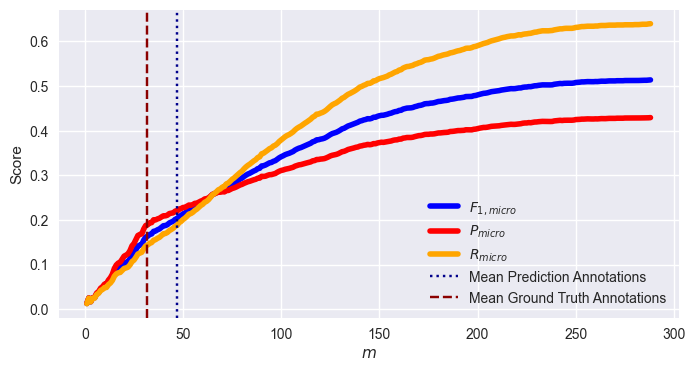

In [ ]:
vary_over_k(
    fn="eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json",
    max_k=None,
    out_file="f1_at_k_nerd.tex",
    score_method=eval_submission_NERD,
    score_name="entities",
    title="Scores @  $k$ for Subtask 6.1.2 with NED finetune + Beam Serach to End + Naive Enrichment using Hermes 3B",
)

In [ ]:
# vary_over_k(
#     fn="eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json",
#     max_k=None,
#     out_file="f1_at_k_re.tex",
#     score_method=eval_submission_mention_level_RE,
#     score_name="mention_level_relations",
#     title="Scores @  $k$ for Subtask 6.2.1 with Hermes 8B Lora",
# )

=== Removed 301 duplicated concept-level relations from predictions ===
Using max_k=78 based on predictions with average number of annotations: 12.31 (sets: 3.00) and average number of GT annotations: 11.11, max_k=78
Further mode: False
Found 0 json files in ../data/results_dev/eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json.
Considering file: ../data/results_dev/eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json with k limits: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78] for finetune type: None
Skipping 1/../data/results_dev/eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json due to all zero scores.
=== Removed 3 dup

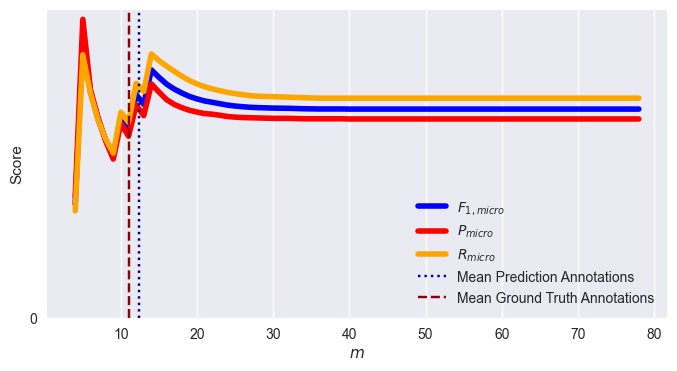

In [ ]:
vary_over_k(
    fn="eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json",
    max_k=None,
    out_file="f1_at_k_red.tex",
    score_method=eval_submission_concept_level_RE,
    score_name="concept_level_relations",
    title="Scores @  $k$ for Subtask 6.2.2 with Hermes 8B Lora",
)